In [3]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations
import argparse

REPO_ROOT = "/sdf/data/rubin/user/mrakovci/Projects/Asteroid_detection_CNN"
DATASET_CREATION = f"{REPO_ROOT}/ADCNN/data/dataset_creation"

for p in [REPO_ROOT, DATASET_CREATION]:
    if p not in sys.path:
        sys.path.insert(0, p)
        
from ADCNN.data.dataset_creation.common import ensure_dir
from ADCNN.data.dataset_creation.simulate_inject import one_detector_injection, select_good_refs_random_check

from lsst.daf.butler import Butler
import numpy as np
import concurrent.futures
from multiprocessing import Lock, Semaphore, Manager
import os
from multiprocessing import Value, Lock
import logging
import pandas as pd
import traceback

import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lsst.daf.butler as dafButler
import lsst.geom as geom
import logging

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import concurrent.futures
import traceback

def worker_df(args):
    """
    Run one_detector_injection for one (visit,detector) with point sources around m5.
    Returns: (status, dataId, err, tb, df)
    """
    (dataId, repo, coll, number, trail_length, mag_range, beta, source_type, seed, mag_mode, psf_template) = args

    # stable per (visit,detector)
    s = (int(seed) * 1_000_003 + int(dataId["visit"]) * 1_003 + int(dataId["detector"])) & 0xFFFFFFFF

    butler = dafButler.Butler(REPO, collections=COLLECTIONS)
    dims = butler.get("preliminary_visit_image.dimensions", dataId=dataId)

    res = one_detector_injection(
        number,
        trail_length,
        mag_range,
        beta,
        repo,
        coll,
        dims,
        source_type,
        dataId,
        s,
        debug=False,
        mag_mode=mag_mode,
        psf_template=psf_template,
    )

    if res[0] is False:
        _, bad_dataId, err, tb = res
        return ("err", dataId, err, tb, None)

    _, img, mask, real_labels, catalog = res
    df = catalog.to_pandas()
    df["visit"] = int(dataId["visit"])
    df["detector"] = int(dataId["detector"])
    return ("ok", dataId, None, None, df)


def run_injections_df_for_detectors(det_df, *, repo, coll, n_inject, mag_offset, trail_length, beta,
                                   parallel, seed, mag_mode, psf_template):
    """
    For each (visit,detector) in det_df (with column m5_stack), inject point sources in [m5-Δ, m5+Δ]
    and return concatenated DataFrame + errors.
    """
    tasks = []
    for r in det_df.itertuples(index=False):
        dataId = {"instrument": "LSSTCam", "exposure": int(r.visit), "visit": int(r.visit), "detector": int(r.detector)}
        mag_range = [float(r.m5_stack) - mag_offset, float(r.m5_stack) + mag_offset]
        tasks.append((dataId, repo, coll, n_inject, trail_length, mag_range, beta,
                      "preliminary_visit_image", seed, mag_mode, psf_template))

    dfs = []
    errors = []
    total = len(tasks)

    if parallel > 1:
        with concurrent.futures.ProcessPoolExecutor(max_workers=parallel) as ex:
            futs = [ex.submit(worker_df, t) for t in tasks]
            done = 0
            for fut in concurrent.futures.as_completed(futs):
                done += 1
                status, dataId, err, tb, df = fut.result()
                if status == "ok":
                    dfs.append(df)
                    print(f"[{done}/{total}] ok visit={dataId['visit']} det={dataId['detector']}", flush=True)
                else:
                    errors.append((dataId, err, tb))
                    print(f"[{done}/{total}] ERROR visit={dataId['visit']} det={dataId['detector']}", flush=True)
                    print(err, flush=True)
                    print(tb, flush=True)
    else:
        for i, t in enumerate(tasks, 1):
            status, dataId, err, tb, df = worker_df(t)
            if status == "ok":
                dfs.append(df)
                print(f"[{i}/{total}] ok visit={dataId['visit']} det={dataId['detector']}", flush=True)
            else:
                errors.append((dataId, err, tb))
                print(f"[{i}/{total}] ERROR visit={dataId['visit']} det={dataId['detector']}", flush=True)
                print(err, flush=True)
                print(tb, flush=True)

    out = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    return out, errors

In [5]:
# Butler configuration
REPO = "dp2_prep"
COLLECTIONS = "LSSTCam/runs/DRP/DP2/v30_0_0/DM-53881/stage2"
WHERE="instrument='LSSTCam' AND day_obs>=20250801 AND day_obs<=20250921 AND band in ('u','g','r','i','z','y') "
N_DETECTORS = 20
N_INJECT_PER_DETECTOR = 300
MAG_OFFSET = 0.5
PARALLEL = 3
SEED = 123
TRAIL_LENGTH = [0.0, 0.0]
BETA = [0.0, 0.0]

In [6]:
butler = dafButler.Butler(REPO, collections=COLLECTIONS)

refs = list(set(
    butler.registry.queryDatasets(
        "preliminary_visit_image",
        instrument="LSSTCam",
        findFirst=True,
        where=WHERE
    )
))

print ("Found data:", len(refs))
refs = sorted(refs, key=lambda r: (int(r.dataId["visit"]), int(r.dataId["detector"])))
ref_indexes = np.random.choice(range(len(refs)), N_DETECTORS*5, replace=False)
refs = np.array(refs)[ref_indexes]
dims = butler.get("preliminary_visit_image.dimensions", dataId=refs[0].dataId)

rows = []
current_id = 0
while (len(rows) < N_DETECTORS) and (current_id < len(refs)):
    calexp = butler.get("preliminary_visit_image", dataId=refs[current_id].dataId)
    m5_stack = float(calexp.info.getSummaryStats().magLim)
    if not np.isnan(m5_stack):
        rows.append({
        "visit": int(refs[current_id].dataId["visit"]),
        "detector": int(refs[current_id].dataId["detector"]),
        "m5_stack": m5_stack,})
    current_id+=1
det_df = pd.DataFrame(rows)    

Found data: 464473


In [7]:
det_df

,visit,detector,m5_stack
0,2025082600637,66,22.997266
1,2025082800166,139,23.598817
2,2025081600450,46,22.842096
3,2025081400300,15,22.450523
4,2025081600383,178,23.290714
5,2025081300408,100,23.081355
6,2025080900320,183,22.416514
7,2025081600519,163,22.882504
8,2025081400346,183,23.198150
9,2025081000354,171,21.580737


In [8]:
logger = logging.getLogger("lsst")
logger.setLevel(logging.ERROR)

In [9]:
all_df, errors = run_injections_df_for_detectors(
    det_df,
    repo=REPO,
    coll=COLLECTIONS,
    n_inject=N_INJECT_PER_DETECTOR,
    mag_offset=MAG_OFFSET,
    trail_length=TRAIL_LENGTH,
    beta=BETA,
    parallel=PARALLEL,
    seed=SEED,
    mag_mode="surface_brightness",
    psf_template="kernel",
)

print("rows:", len(all_df), "errors:", len(errors))
all_df.head()

[1/20] ok visit=2025082600637 det=66
[2/20] ok visit=2025082800166 det=139
[3/20] ok visit=2025081600383 det=178
[4/20] ok visit=2025081400300 det=15
[5/20] ok visit=2025081300408 det=100
[6/20] ok visit=2025080900320 det=183
[7/20] ok visit=2025081600519 det=163
[8/20] ok visit=2025081400346 det=183
[9/20] ok visit=2025081600450 det=46
[10/20] ok visit=2025081000354 det=171
[11/20] ok visit=2025082600511 det=143
[12/20] ok visit=2025081300416 det=11
[13/20] ok visit=2025081600505 det=70
[14/20] ok visit=2025081000295 det=124
[15/20] ok visit=2025090600498 det=184
[16/20] ok visit=2025090600318 det=16
[17/20] ok visit=2025081300334 det=22
[18/20] ok visit=2025080600407 det=154
[19/20] ok visit=2025090600434 det=119
[20/20] ok visit=2025090600416 det=144
rows: 6000 errors: 0


,ra,dec,source_type,trail_length,mag,beta,visit,detector,integrated_mag,PSF_mag,...,physical_filter,x,y,SNR_estimation,m5_local,m5_detector,stack_detection,stack_mag,stack_mag_err,stack_snr
0,342.938351,-7.352554,Star,0.0,22.581700,0.0,2025082600637,66,22.581700,22.581700,...,i,288,3470,8.044507,22.405316,22.997266,True,22.734455,0.166050,6.538592
1,342.821144,-7.147470,Star,0.0,23.433493,0.0,2025082600637,66,23.433493,23.433493,...,i,3807,1096,3.704175,22.406681,22.997266,False,NaN,NaN,NaN
2,342.971867,-7.220084,Star,0.0,22.547006,0.0,2025082600637,66,22.547006,22.547006,...,i,2712,3881,8.306138,22.399837,22.997266,True,22.624642,0.149555,7.259803
3,342.799417,-7.267092,Star,0.0,23.263133,0.0,2025082600637,66,23.263133,23.263133,...,i,1629,879,4.322973,22.405266,22.997266,False,NaN,NaN,NaN
4,342.774587,-7.184810,Star,0.0,22.763331,0.0,2025082600637,66,22.763331,22.763331,...,i,3071,321,6.875006,22.411410,22.997266,False,NaN,NaN,NaN


In [10]:
d = all_df.copy()
if len(d) == 0:
    raise RuntimeError("No injection results; check errors above.")

# detected flag is your footprint match result
d["detected"] = d["stack_detection"].astype(bool)

# Join m5_stack for convenience
d = d.merge(det_df, on=["visit", "detector"], how="left")

# Use injected PSF_mag for point sources
mag = d["PSF_mag"].astype(float).values
mmin, mmax = np.nanpercentile(mag, [0.5, 99.5])
bins = np.linspace(mmin, mmax, 25)
d["mag_bin"] = pd.cut(d["PSF_mag"], bins)
d["mag_delta1"] = d["mag"] - d["m5_stack"]
d

,ra,dec,source_type,trail_length,mag,beta,visit,detector,integrated_mag,PSF_mag,...,m5_local,m5_detector,stack_detection,stack_mag,stack_mag_err,stack_snr,detected,m5_stack,mag_bin,mag_delta1
0,342.938351,-7.352554,Star,0.0,22.581700,0.0,2025082600637,66,22.581700,22.581700,...,22.405316,22.997266,True,22.734455,0.166050,6.538592,True,22.997266,"(22.573, 22.695]",-0.415566
1,342.821144,-7.147470,Star,0.0,23.433493,0.0,2025082600637,66,23.433493,23.433493,...,22.406681,22.997266,False,NaN,NaN,NaN,False,22.997266,"(23.425, 23.547]",0.436227
2,342.971867,-7.220084,Star,0.0,22.547006,0.0,2025082600637,66,22.547006,22.547006,...,22.399837,22.997266,True,22.624642,0.149555,7.259803,True,22.997266,"(22.451, 22.573]",-0.450260
3,342.799417,-7.267092,Star,0.0,23.263133,0.0,2025082600637,66,23.263133,23.263133,...,22.405266,22.997266,False,NaN,NaN,NaN,False,22.997266,"(23.182, 23.304]",0.265867
4,342.774587,-7.184810,Star,0.0,22.763331,0.0,2025082600637,66,22.763331,22.763331,...,22.411410,22.997266,False,NaN,NaN,NaN,False,22.997266,"(22.695, 22.817]",-0.233936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,309.543677,-16.225479,Star,0.0,21.340504,0.0,2025090600416,144,21.340504,21.340504,...,20.935114,21.525507,True,21.228550,0.161013,6.743161,True,21.525507,"(21.234, 21.356]",-0.185002
5996,309.594325,-16.209829,Star,0.0,21.302143,0.0,2025090600416,144,21.302143,21.302143,...,20.944319,21.525507,True,21.276515,0.168171,6.456146,True,21.525507,"(21.234, 21.356]",-0.223364
5997,309.476198,-16.098488,Star,0.0,21.951028,0.0,2025090600416,144,21.951028,21.951028,...,20.934890,21.525507,False,NaN,NaN,NaN,False,21.525507,"(21.843, 21.964]",0.425521
5998,309.614650,-16.151136,Star,0.0,21.517240,0.0,2025090600416,144,21.517240,21.517240,...,20.947847,21.525507,False,NaN,NaN,NaN,False,21.525507,"(21.477, 21.599]",-0.008267


Text(0.5, 1.0, 'Point sources, only y band')

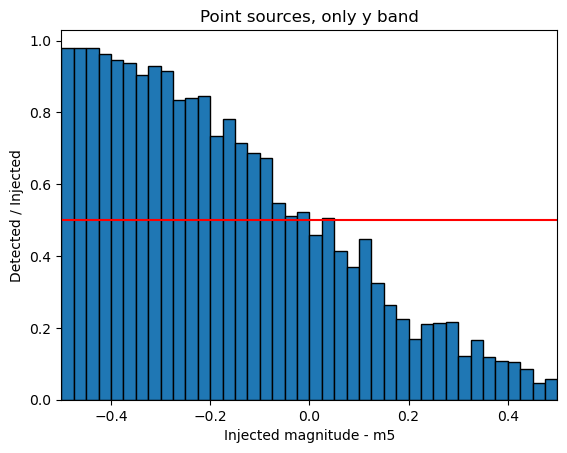

In [11]:
n=41
counts_total, bin_edges = np.histogram (d["mag_delta1"], bins=np.linspace(-0.5, 0.5, n))
counts_detected, bin_edges = np.histogram (d["mag_delta1"][d["detected"]], bins=np.linspace(-0.5, 0.5, n))
plt.bar(bin_edges[:-1], counts_detected/counts_total, width=np.diff(bin_edges), align='edge', edgecolor='black')
plt.xlim(-0.5,0.5)
plt.hlines(0.5, xmin=-1, xmax=1, color="red")
plt.xlabel ("Injected magnitude - m5")
plt.ylabel ("Detected / Injected")
plt.title ("Point sources, only y band")